In [11]:
import pandas as pd
import sqlite3

con = sqlite3.connect('../data/checking-logs.sqlite')

In [12]:
query = """
SELECT timestamp 
FROM checker
WHERE uid NOT LIKE 'admin_%'
"""
df_timestamp= pd.read_sql_query(query, con)
df_timestamp.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370


In [13]:
df_timestamp['date'] = pd.to_datetime(df_timestamp['timestamp']).dt.date
df_timestamp['hour'] = pd.to_datetime(df_timestamp['timestamp']).dt.hour
df_timestamp['weekday'] = pd.to_datetime(df_timestamp['timestamp']).dt.weekday
df_timestamp.head()

,timestamp,date,hour,weekday
0,2020-04-17 05:19:02.744528,2020-04-17,5,4
1,2020-04-17 05:22:35.249331,2020-04-17,5,4
2,2020-04-17 05:22:45.549397,2020-04-17,5,4
3,2020-04-17 05:34:14.691200,2020-04-17,5,4
4,2020-04-17 05:34:24.422370,2020-04-17,5,4


In [14]:
df_timestamp["day_type"] = df_timestamp["weekday"].apply(lambda x: "working_day" if x in (0,1,2,3,4) else "weekend")

In [15]:
day_commits = df_timestamp.groupby(["date", "hour", "day_type"]).size().reset_index(name = "commits")
len(day_commits)

288

In [16]:
avg_hour_commits = day_commits.groupby(["hour", "day_type"])["commits"].mean().reset_index(name = "hour_commits")

In [17]:
f_table = avg_hour_commits.pivot(index = "hour", columns = "day_type", values = "hour_commits")

In [18]:
f_table.loc[17]

day_type
weekend         7.142857
working_day    16.000000
Name: 17, dtype: float64

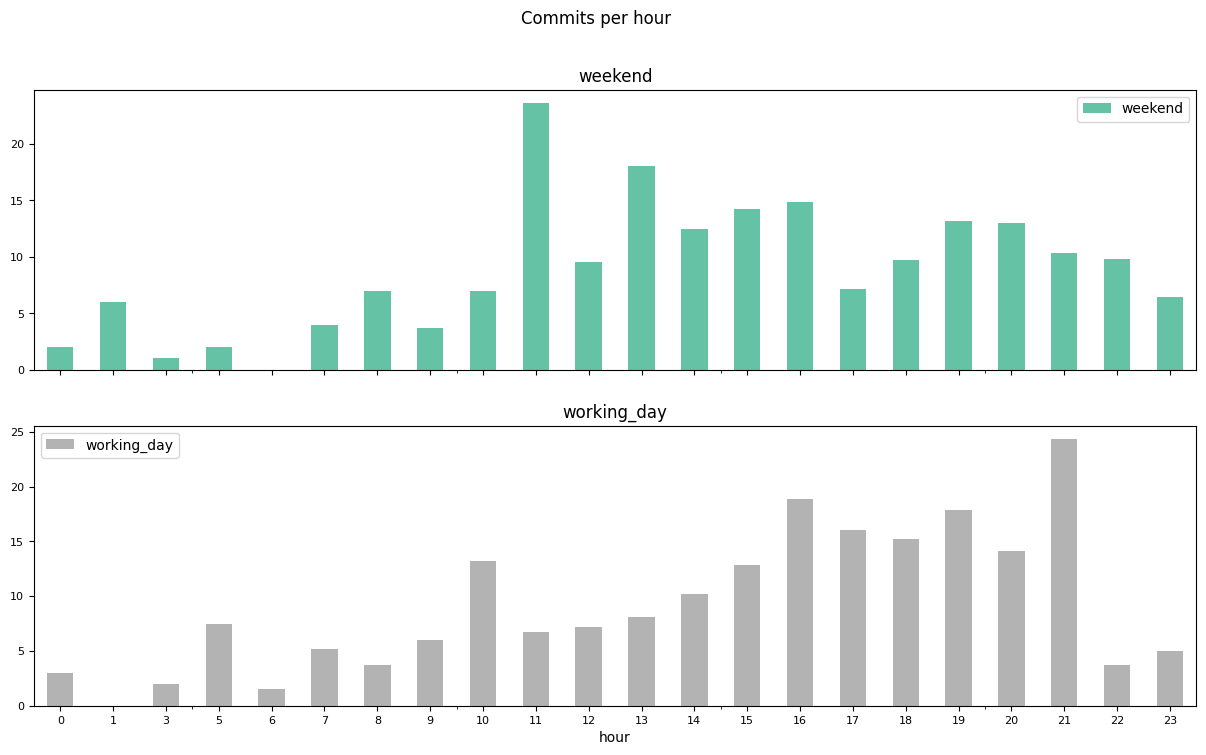

In [19]:
plott = f_table.plot(figsize = (15,8), fontsize = 8, 
                    kind = "bar", colormap = "Set2" , 
                    title = "Commits per hour",
                    rot= 0,
                    subplots = True)

In [20]:
con.close()

 "Is the dynamic different on working days and weekends?" For the answer, include the hour when the number of commits is largest during working days and the hour when it is largest during the weekend.

 21 час в рабочие 

 11 часов в выходные